# FraudShield - Financial Fraud Detection

## 1. Business Problem

Financial fraud causes significant financial losses to banks and customers every year. The objective of this project is to develop a machine learning model that can accurately classify fraudulent and legitimate transactions using customer and transaction information.


## 2. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import utils as ut



ModuleNotFoundError: No module named 'src'


## 3. Load Dataset

In [ ]:
data = pd.read_csv("../data/raw/fraudTest.csv")
df = pd.DataFrame(data)
df.head()

,,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


## 4. Dataset Overview

### 4.1 Dataset Shape

**Observation**
- Large dataset suitable for machine learning.
- Dataset contains transaction and customer information.

### 4.2 Dataset Information

**Observation**
- Dataset contains numerical and categorical features.
- Target column is `is_fraud`.

### 4.3 Missing Values

**Observation**
- No missing values found.
- No imputation required.

### 4.4 Duplicate Values

**Observation**
- No duplicate records found.

### 4.5 Data Types

**Observation**
- Dataset contains both numerical and categorical variables.

In [ ]:
print(df.info())
print(df.shape)
print(df.duplicated().sum())
print(df.isnull().sum())
df.select_dtypes(include=['object','category']).nunique()

<class 'pandas.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0                          555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  str    
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  str    
 4   category               555719 non-null  str    
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  str    
 7   last                   555719 non-null  str    
 8   gender                 555719 non-null  str    
 9   street                 555719 non-null  str    
 10  city                   555719 non-null  str    
 11  state                  555719 non-null  str    
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-null  float64

C:\Users\dell\AppData\Local\Temp\ipykernel_14748\3022576539.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=['object','category']).nunique()


trans_date_trans_time    544760
merchant                    693
category                     14
first                       341
last                        471
gender                        2
street                      924
city                        849
state                        50
job                         478
dob                         910
trans_num                555719
dtype: int64

Observation:
 Dataset contains 555,719 rows and 23 columns.
 Large dataset suitable for ML.
 Their is no duplicate value
 their is no null value or missing value
 

In [ ]:
fraud_tran = df[df['is_fraud']==1]
notfraud_tran = df[df['is_fraud']==0]
total_fraud_tran = len(fraud_tran)
total_notfraud_tran = len(notfraud_tran)
fraud_tran


,,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
1685,1685,2020-06-21 22:06:39,3560725013359375,fraud_Hamill-D'Amore,health_fitness,24.84,Brooke,Smith,F,63542 Luna Brook Apt. 012,...,31.8599,-102.7413,23,Cytogeneticist,1969-09-15,16bf2e46c54369a8eab2214649506425,1371852399,32.575873,-102.604290,1
1767,1767,2020-06-21 22:32:22,6564459919350820,"fraud_Rodriguez, Yost and Jenkins",misc_net,780.52,Douglas,Willis,M,619 Jeremy Garden Apt. 681,...,42.5545,-90.3508,1306,Public relations officer,1958-09-10,ab4b379d2c0c9c667d46508d4e126d72,1371853942,42.461127,-91.147148,1
1781,1781,2020-06-21 22:37:27,6564459919350820,fraud_Nienow PLC,entertainment,620.33,Douglas,Willis,M,619 Jeremy Garden Apt. 681,...,42.5545,-90.3508,1306,Public relations officer,1958-09-10,47a9987ae81d99f7832a54b29a77bf4b,1371854247,42.771834,-90.158365,1
1784,1784,2020-06-21 22:38:55,4005676619255478,"fraud_Heathcote, Yost and Kertzmann",shopping_net,1077.69,William,Perry,M,458 Phillips Island Apt. 768,...,30.4590,-90.9027,71335,Herbalist,1994-05-31,fe956c7e4a253c437c18918bf96f7b62,1371854335,31.204974,-90.261595,1
1857,1857,2020-06-21 23:02:16,3560725013359375,fraud_Hermann and Sons,shopping_pos,842.65,Brooke,Smith,F,63542 Luna Brook Apt. 012,...,31.8599,-102.7413,23,Cytogeneticist,1969-09-15,f6838c01f5d2262006e6b71d33ba7c6d,1371855736,31.315782,-102.736390,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517197,517197,2020-12-22 22:05:48,2242176657877538,"fraud_Willms, Kris and Bergnaum",shopping_pos,1041.51,Travis,Daniel,M,1327 Rose Causeway Apt. 610,...,34.6323,-89.8855,14462,Database administrator,1959-03-03,35b0297dd026d2e9a75d024a5dec7955,1387749948,34.573471,-89.911011,1
517274,517274,2020-12-22 22:18:07,2242176657877538,fraud_Kuhn LLC,shopping_pos,868.09,Travis,Daniel,M,1327 Rose Causeway Apt. 610,...,34.6323,-89.8855,14462,Database administrator,1959-03-03,da7f67d7375f10a054a3d919448c45dd,1387750687,34.091227,-90.390612,1
517341,517341,2020-12-22 22:31:48,2242176657877538,"fraud_Mosciski, Ziemann and Farrell",shopping_net,1039.42,Travis,Daniel,M,1327 Rose Causeway Apt. 610,...,34.6323,-89.8855,14462,Database administrator,1959-03-03,25b076c7bcd70f272c1c5326bb234f4b,1387751508,34.628434,-90.284780,1
517529,517529,2020-12-22 23:06:03,2242176657877538,fraud_Bauch-Raynor,grocery_pos,289.27,Travis,Daniel,M,1327 Rose Causeway Apt. 610,...,34.6323,-89.8855,14462,Database administrator,1959-03-03,2df7d894868fbc99ec1d8b055585fc9d,1387753563,34.746063,-90.401093,1


## 5. Target Variable Analysis

## 1. plotting barchat for checking weather dataset is imbalance or not
## 2. plotting 2nd barchat for checking which merchant have high fraud transaction history 

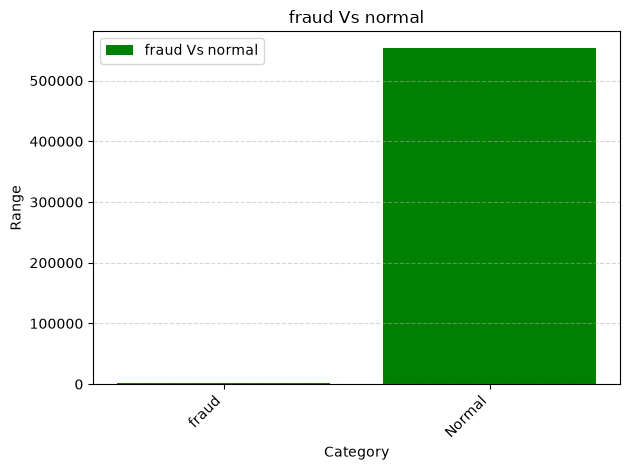

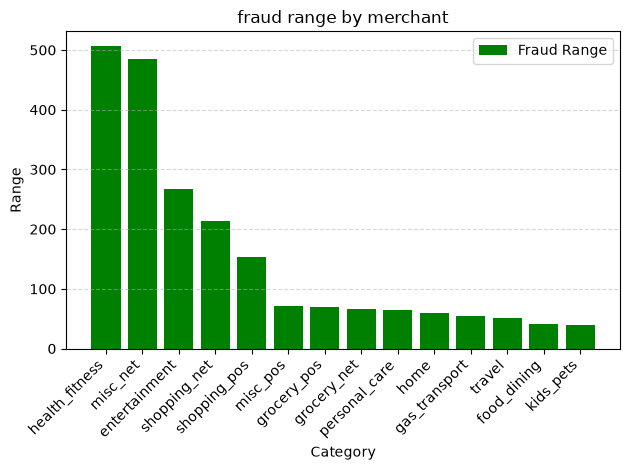

In [ ]:
ut.plot_barchat(X_axis=['fraud','Normal'],y_axis=[total_fraud_tran,total_notfraud_tran],label_var='fraud Vs normal',title_var='fraud Vs normal')
fraud_unique_value =fraud_tran['category'].unique()
fraud_range = fraud_tran['category'].value_counts()
ut.plot_barchat(X_axis=fraud_unique_value,y_axis=fraud_range,label_var='Fraud Range',title_var='fraud range by merchant')

# 1st bar chat :
     Dataset is highly imbalanced.
     Fraud transactions are much fewer than normal transactions.
     Accuracy alone is not a suitable evaluation metric.

# 2nd bar chat:
    Health_fitness and misc_net show the highest fraud frequency in the dataset.
    where kids pets have very low fraud frequency 

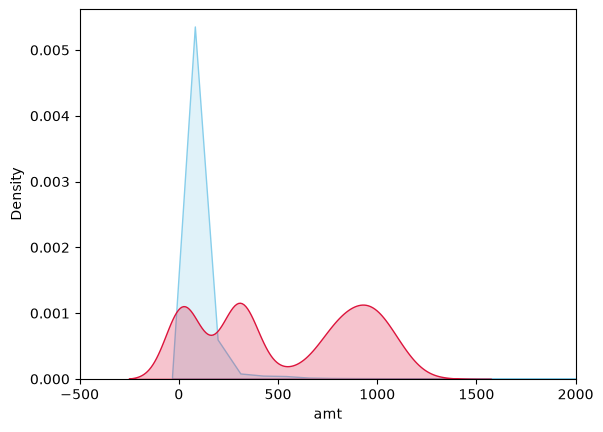

In [ ]:
sns.kdeplot(data=notfraud_tran, x='amt', label='Legitimate', fill=True, color='skyblue')
sns.kdeplot(data=fraud_tran, x='amt', label='Fraudulent', fill=True, color='crimson')
plt.xlim(-500, 2000)
plt.show()

## 8. Feature Engineering Ideas

- Night Transaction
- Merchant Fraud Rate
- Customer-Merchant Distance
- Previous Spending Difference
- Rapid Transaction Velocity
- Merchant Repeat Frequency
- Category + Amount Interaction
- Customer Transaction History
- Time + Merchant Interaction
- Impossible Travel Detection


## 9. Key Findings

- Dataset is highly imbalanced.
- Amount alone is insufficient for fraud detection.
- Behavioral features are more informative than identity features.
- Feature engineering is expected to improve model performance.
- Merchant and transaction behavior provide valuable fraud signals.


## 10. Next Step

Feature Engineering → Data Preprocessing → Model Training → Model Evaluation → Deployment